In [1]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch
import torchvision
import torchvision.transforms as transforms
import pandas as pd
import numpy as np

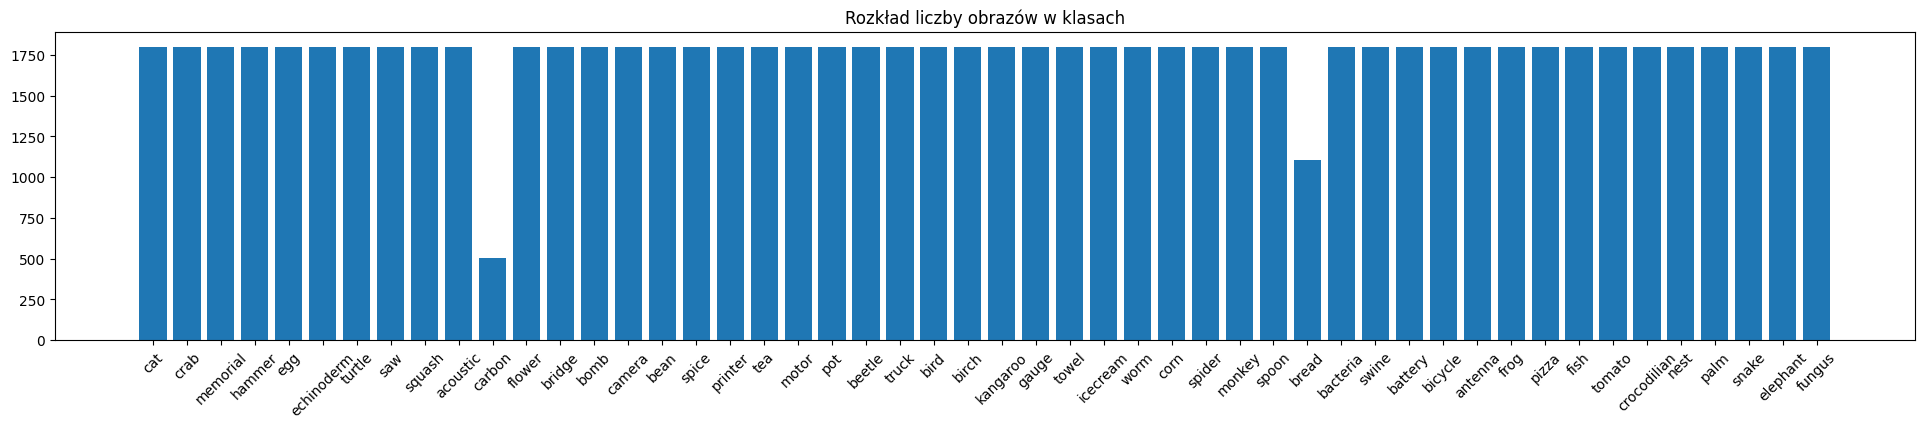

In [2]:
import matplotlib.pyplot as plt
import os
from collections import Counter


data_dir = "data/train"
class_counts = Counter(
    [
        folder
        for folder in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, folder))
    ]
)

plt.figure(figsize=(24, 4))
labels, counts = zip(
    *[
        (cls, len(os.listdir(os.path.join(data_dir, cls))))
        for cls in os.listdir(data_dir)
    ]
)
plt.bar(labels, counts)
plt.xticks(rotation=45)
plt.title("Rozkład liczby obrazów w klasach")
plt.show()


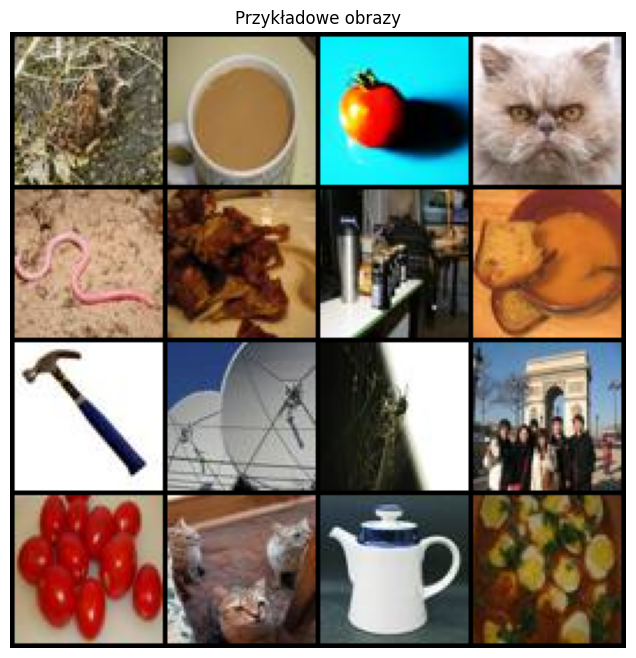

In [3]:
transform = transforms.ToTensor()
dataset = ImageFolder(root=data_dir, transform=transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

images, labels = next(iter(loader))

grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.title("Przykładowe obrazy")
plt.axis("off")
plt.show()

In [4]:
from PIL import Image

image_shapes = []
for cls in os.listdir(data_dir):
    for filename in os.listdir(os.path.join(data_dir, cls)):
        img_path = os.path.join(data_dir, cls, filename)
        with Image.open(img_path) as img:
            image_shapes.append(img.size)


shape_counts = Counter(image_shapes)
print("Rozmiary obrazów i ich liczność:")
for shape, count in shape_counts.items():
    print(f"{shape}: {count}")


Rozmiary obrazów i ich liczność:
(64, 64): 88011
